# Лабораторная работа №3

Егорова Варвара Александровна, 408575, P3323

## Задание:
Для выполнение лабораторной работы необходимо выполнить следующие пункты:
1. Придумать эргодическую марковскую цепь, содержащую не менее 4-х состояний.
2. Нарисовать диаграмму переходов и записать матрицу переходных вероятностей данной цепи.
3. Промоделировать марковскую цепь пошагово с несколькими различными начальными векторами вероятностей состояний и получить конечные вектора, к которым привело моделирование.
4. Построить графики изменения компонентов финальных векторов, а также графики изменения среднеквадратического отклонения на каждом шаге моделирования для всех начальных векторов.
5. Найти стационарное распределение аналитически (см. пример в презентации).
6. Сравнить вектора из пункта 3 и вектор, рассчитанный аналитически, между собой.

Замечания:
1. При пошаговом моделировании необязательно хранить все значения стационарного вектора, можно иметь два вектора вероятностей – старый и новый, главное, после применения формулы переписать значение из нового в старое и далее можно совершить еще один шаг моделирования (вычислить новый вектор). Вычисления продолжаются до тех пор, пока  среднеквадратичное отклонение между старым и новым вектором не будет меньше заданного значения  ошибки e.
2. Для нахождения аналитического решения вектора стационарного распределения можно использовать функцию numpy.linalg.solve.

Описание предметной области:
Состояния студента, который хаотично перемещается между ними.

Возможные состояния:
- Учеба
- Прокрастинация
- Сон
- Паника

In [ ]:
import numpy as np
import random as rm

states = ['study', 'procrastination', 'sleep', 'panic']

transition_name = [['StSt', 'StPr', 'StSl', 'StPa'],
                    ['PrSt', 'PrPr', 'PrSl', 'PrPa'],
                    ['SlSt', 'SlPr', 'SlSl', 'SlPa'],
                    ['PaSt', 'PaPr', 'PaSl', 'PaPa']]

transition_matrix = np.array([[0.1, 0.3, 0.4, 0.2],
                      [0.2, 0.5, 0.2, 0.1],
                      [0.2, 0.1, 0.6, 0.1],
                      [0.4, 0.2, 0.2, 0.2]])

In [ ]:
def mse(p_old, p_new):
    return np.sqrt(np.mean((p_new - p_old) ** 2))


def markov_process(p0, P, eps=1e-5, max_steps=100):
    p_old = np.array(p0)
    history = [p_old.copy()]
    errors = []

    for step in range(max_steps):
        p_new = p_old @ P
        error = mse(p_old, p_new)

        history.append(p_new.copy())
        errors.append(error)

        if error < eps:
            break

        p_old = p_new

    return np.array(history), np.array(errors)

In [ ]:
initial_vectors = [
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.25, 0.25, 0.25, 0.25]
]

In [ ]:
results = []

for p0 in initial_vectors:
    history, errors = markov_process(p0, transition_matrix)
    results.append((history, errors))

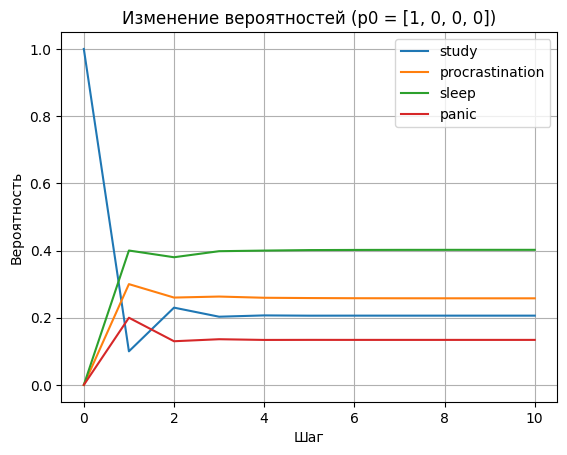

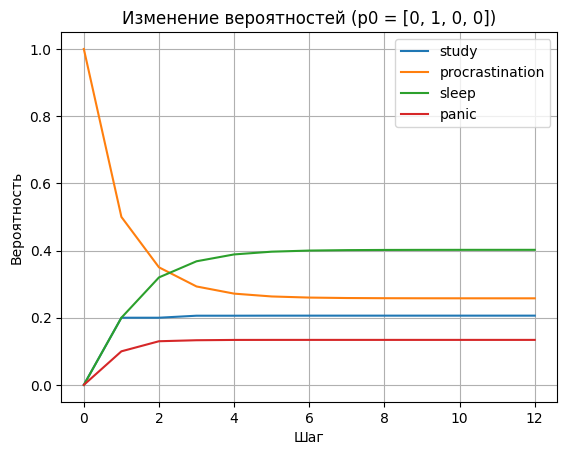

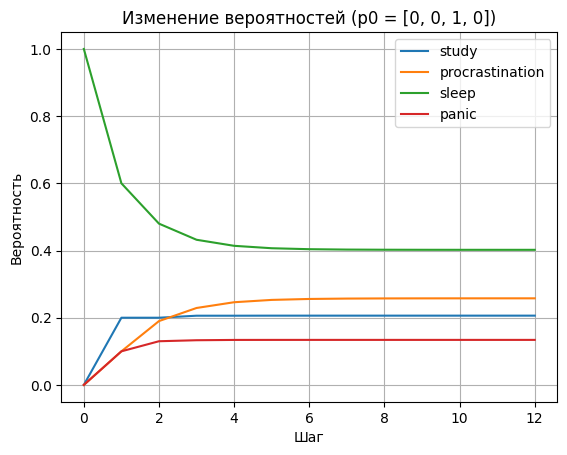

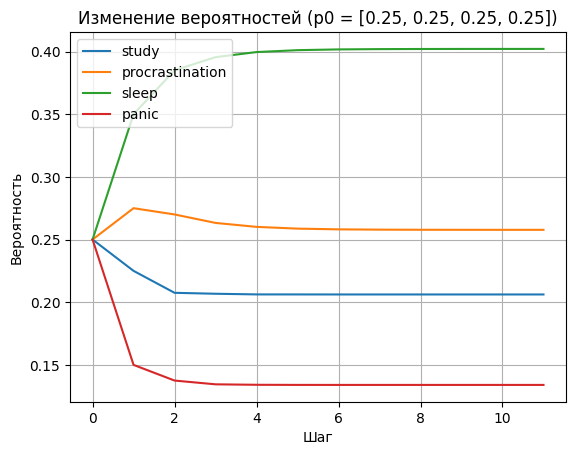

In [ ]:
import matplotlib.pyplot as plt

for i, (history, errors) in enumerate(results):
    plt.figure()
    for j in range(len(states)):
        plt.plot(history[:, j], label=states[j])

    plt.title(f'Изменение вероятностей (p0 = {initial_vectors[i]})')
    plt.xlabel('Шаг')
    plt.ylabel('Вероятность')
    plt.legend()
    plt.grid()
    plt.show()

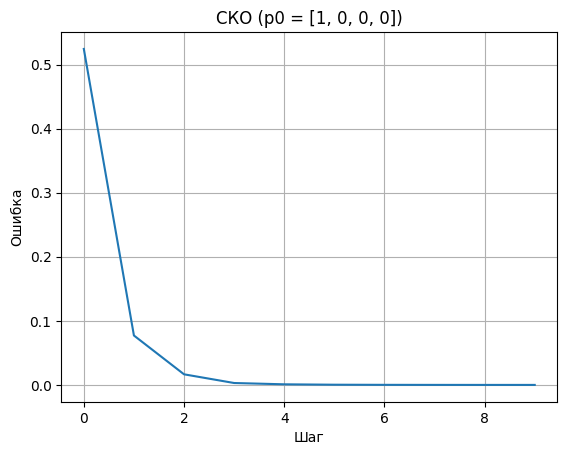

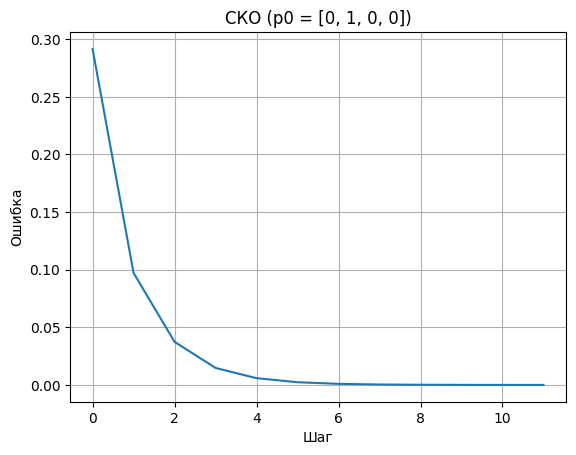

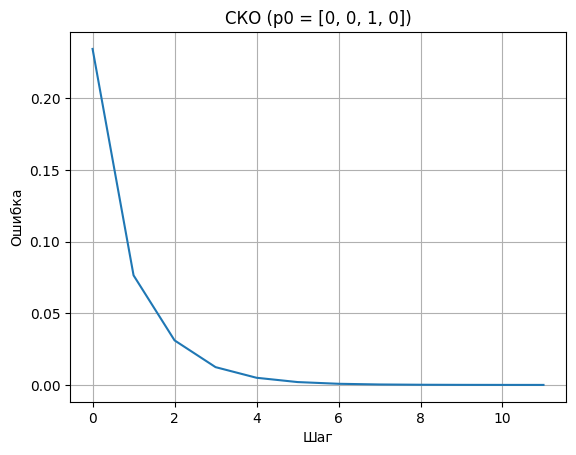

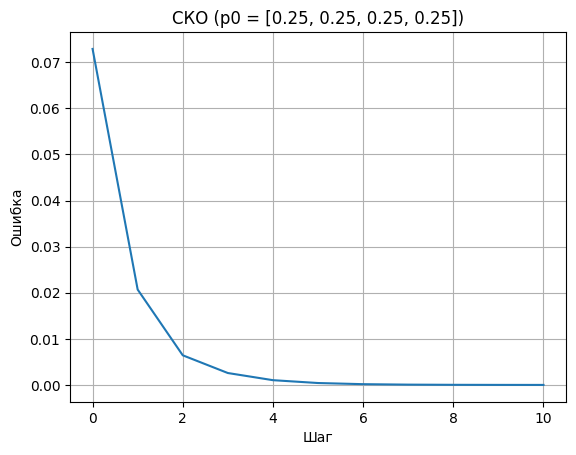

In [ ]:
for i, (history, errors) in enumerate(results):
    plt.figure()
    plt.plot(errors)

    plt.title(f'СКО (p0 = {initial_vectors[i]})')
    plt.xlabel('Шаг')
    plt.ylabel('Ошибка')
    plt.grid()
    plt.show()

In [ ]:
for i, (history, _) in enumerate(results):
    print(f"Начальный вектор: {initial_vectors[i]}")
    print("Финальный вектор:", history[-1])
    print()

Начальный вектор: [1, 0, 0, 0]
Финальный вектор: [0.20618559 0.25774002 0.40205378 0.13402062]

Начальный вектор: [0, 1, 0, 0]
Финальный вектор: [0.20618557 0.25774099 0.40205282 0.13402062]

Начальный вектор: [0, 0, 1, 0]
Финальный вектор: [0.20618557 0.25772422 0.4020696  0.13402062]

Начальный вектор: [0.25, 0.25, 0.25, 0.25]
Финальный вектор: [0.20618557 0.25773599 0.40205782 0.13402062]



Аналитическое решение

In [ ]:
n = transition_matrix.shape[0]

# Формируем систему (P^T - I)
A = transition_matrix.T - np.eye(n)

# Заменяем последнюю строку на условие нормировки
A[-1] = np.ones(n)

b = np.zeros(n)
b[-1] = 1

pi = np.linalg.solve(A, b)

print("Стационарное распределение:")
print(pi)

Стационарное распределение:
[0.20618557 0.25773196 0.40206186 0.13402062]


In [ ]:
print("Сравнение с моделированием:\n")

for i, (history, _) in enumerate(results):
    print(f"Начальный вектор: {initial_vectors[i]}")
    print("Численный результат:", history[-1])
    print("Аналитический:", pi)

    diff = np.linalg.norm(history[-1] - pi)
    print("Разница (норма):", diff)
    print()

Сравнение с моделированием:

Начальный вектор: [1, 0, 0, 0]
Численный результат: [0.20618559 0.25774002 0.40205378 0.13402062]
Аналитический: [0.20618557 0.25773196 0.40206186 0.13402062]
Разница (норма): 1.1406861973645426e-05

Начальный вектор: [0, 1, 0, 0]
Численный результат: [0.20618557 0.25774099 0.40205282 0.13402062]
Аналитический: [0.20618557 0.25773196 0.40206186 0.13402062]
Разница (норма): 1.2775878198819479e-05

Начальный вектор: [0, 0, 1, 0]
Численный результат: [0.20618557 0.25772422 0.4020696  0.13402062]
Аналитический: [0.20618557 0.25773196 0.40206186 0.13402062]
Разница (норма): 1.0950688212564101e-05

Начальный вектор: [0.25, 0.25, 0.25, 0.25]
Численный результат: [0.20618557 0.25773599 0.40205782 0.13402062]
Аналитический: [0.20618557 0.25773196 0.40206186 0.13402062]
Разница (норма): 5.7033711315162936e-06

